# 🎬 JOINTS X INSPIRE 2026 - Data Science Competition
## High-Performance Box Office Forecasting System: Predict Cinema Ticket Sales (D4–D10)
---
### 📌 Executive Summary & Methodology
- **Objective**: Predict daily ticket sales (`total_ticket`) for the first full week of screening (Days 4 to 10) given the first 3 days of opening weekend history (Days 1 to 3) across Indonesian cinema theaters.
- **Evaluation Metric**: **Mean Absolute Scaled Error (MASE)**
  $$\mathrm{MASE} = \frac{1}{N} \sum_{i=1}^N \frac{|y_i - \hat{y}_i|}{s_{p(i)}}, \quad s_p = \max\left( \frac{1}{3} \sum_{d=1}^3 y_{p,d}, 1 \right)$$
- **Mathematical Optimization Insight**:
  By defining the normalized ratio target $z_i = \frac{y_i}{s_{p(i)}}$, training gradient boosted trees with an **L1 / MAE loss function** (`regression_l1` / `MAE` / `reg:absoluteerror`) directly minimizes the exact evaluation metric MASE:
  $$\mathrm{MAE}(z, \hat{z}) = \frac{1}{N} \sum_{i=1}^N |z_i - \hat{z}_i| \equiv \mathrm{MASE}$$
- **Validation Strategy**: **5-Fold GroupKFold** grouped strictly on `movie_title` to guarantee zero information leakage across unseen test movies.
- **Ensemble Arsenal**: High-capacity multi-family gradient boosting:
  1. **LightGBM Regressor** (Leaf-wise histogram boosting)
  2. **CatBoost Regressor** (Symmetric oblivious decision trees with categorical handling)
  3. **XGBoost Regressor** (Depth-wise gradient boosting with GPU acceleration)
  Followed by **L1-Constrained Nelder-Mead Blending** and optimal post-processing calibration.


## 1. Setup Environment & Reproducibility


In [1]:
# Pinned dependencies installation in quiet mode as required by TM guidelines
!pip install -q lightgbm==4.6.0 xgboost==3.1.2 catboost==1.2.10 scikit-learn==1.6.1 scipy==1.15.2

import os
import re
import gc
import time
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error
from scipy.optimize import minimize

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Fixed global random state for strict reproducibility
SEED = 2026
np.random.seed(SEED)
print(f"Environment successfully initialized with SEED = {SEED}")


Environment successfully initialized with SEED = 2026


## 2. Data Acquisition & Integrity Verification
Loading all official competition datasets provided in the package.


In [2]:
train_raw = pd.read_csv('data/train.csv')
test_raw = pd.read_csv('data/test.csv')
test_hist_raw = pd.read_csv('data/test_history.csv')
movies_df = pd.read_csv('data/movies.csv')
holidays_df = pd.read_csv('data/holidays.csv')
prices_df = pd.read_csv('data/ticket_prices.csv')

print(f"Dataset Shapes:")
print(f"  train.csv        : {train_raw.shape}")
print(f"  test.csv         : {test_raw.shape}")
print(f"  test_history.csv : {test_hist_raw.shape}")
print(f"  movies.csv       : {movies_df.shape}")
print(f"  holidays.csv     : {holidays_df.shape}")
print(f"  ticket_prices.csv: {prices_df.shape}")

display(train_raw.head(3))


Dataset Shapes:
  train.csv        : (138959, 7)
  test.csv         : (72611, 5)
  test_history.csv : (32323, 7)
  movies.csv       : (397, 7)
  holidays.csv     : (366, 4)
  ticket_prices.csv: (207, 3)


,date_show,cinema_ids,city_name,movie_title,total_ticket,occupation_rate,total_show
0,2025-04-01,015555fbcd8faef6b55a854605df0a87,SURABAYA,A WORKING MAN,487,31.07,18
1,2025-04-01,015555fbcd8faef6b55a854605df0a87,SURABAYA,JUMBO,649,23.69,19
2,2025-04-01,015555fbcd8faef6b55a854605df0a87,SURABAYA,KOMANG,389,9.55,22


## 3. Exploratory Data Analysis (EDA)
Analyzing target distribution, opening momentum, weekend spikes, and Indonesian holiday dynamics.


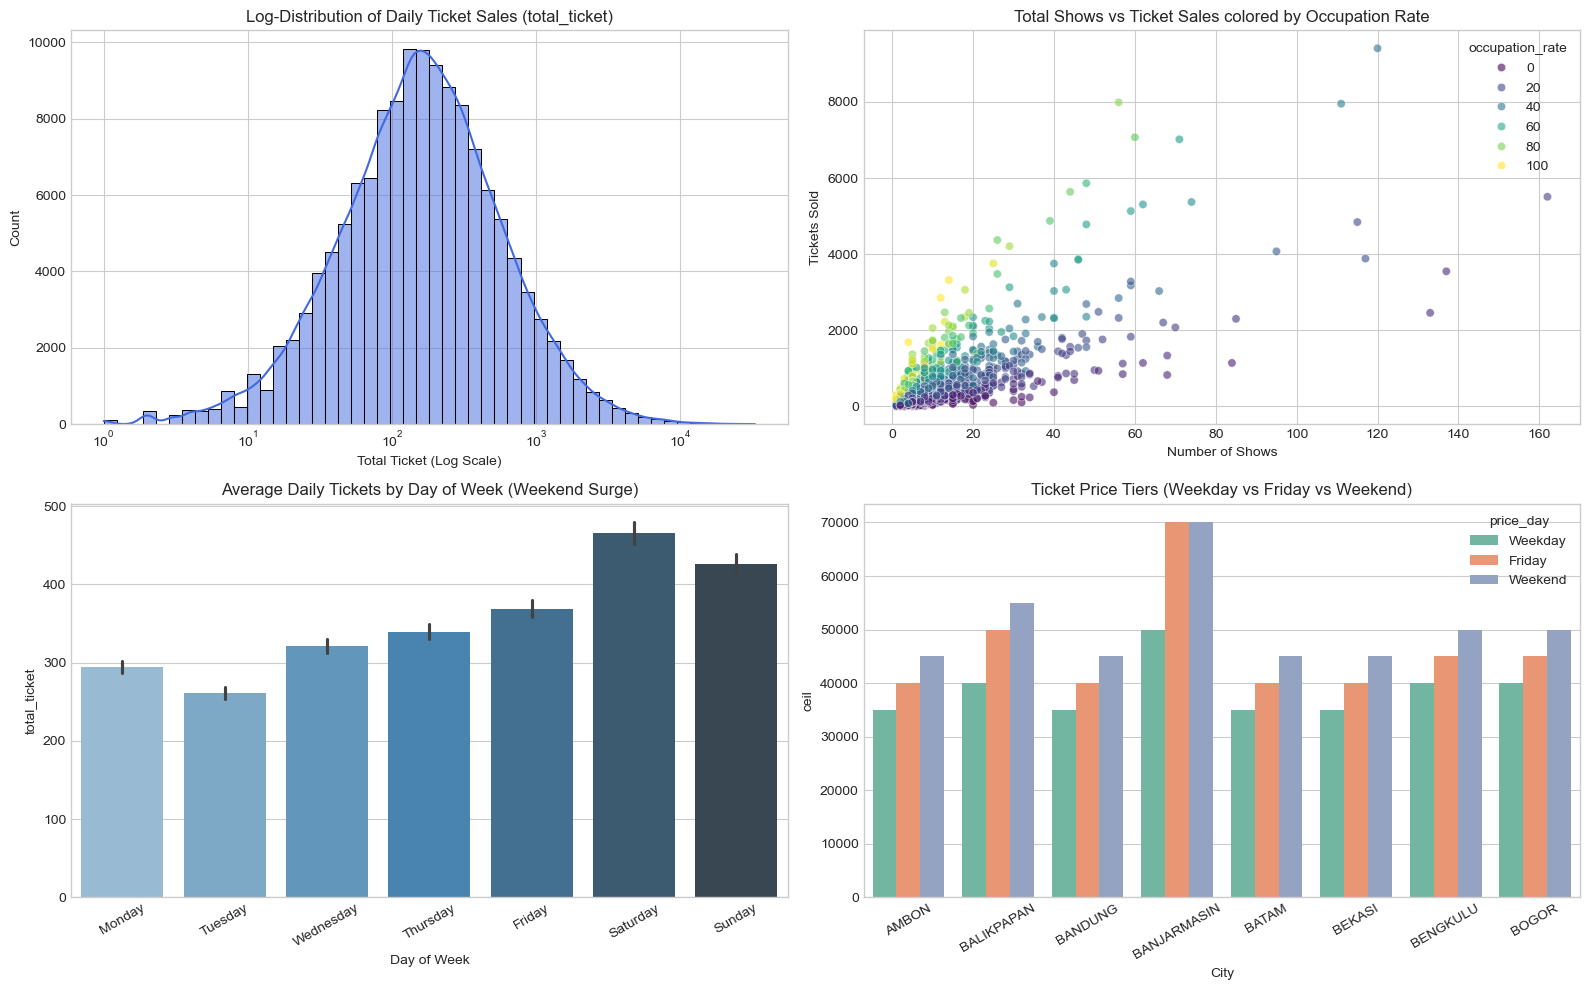

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Target total_ticket distribution (Log scale)
sns.histplot(train_raw['total_ticket'], bins=50, kde=True, ax=axes[0, 0], color='royalblue', log_scale=True)
axes[0, 0].set_title('Log-Distribution of Daily Ticket Sales (total_ticket)')
axes[0, 0].set_xlabel('Total Ticket (Log Scale)')

# 2. Total Shows vs Total Ticket
sns.scatterplot(data=train_raw.sample(3000, random_state=SEED), x='total_show', y='total_ticket', 
                hue='occupation_rate', palette='viridis', alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title('Total Shows vs Ticket Sales colored by Occupation Rate')
axes[0, 1].set_xlabel('Number of Shows')
axes[0, 1].set_ylabel('Tickets Sold')

# 3. Day of week distribution in train
train_raw['date_dt'] = pd.to_datetime(train_raw['date_show'])
train_raw['dow'] = train_raw['date_dt'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=train_raw, x='dow', y='total_ticket', order=dow_order, ax=axes[1, 0], palette='Blues_d')
axes[1, 0].set_title('Average Daily Tickets by Day of Week (Weekend Surge)')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].tick_params(axis='x', rotation=30)

# 4. Cinema Ticket Prices across Top Cities
top_cities = prices_df['city_name'].value_counts().head(8).index
sns.barplot(data=prices_df[prices_df['city_name'].isin(top_cities)], x='city_name', y='ceil', 
            hue='price_day', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Ticket Price Tiers (Weekday vs Friday vs Weekend)')
axes[1, 1].set_xlabel('City')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 4. Preprocessing & Clean Consecutive Wide-Release Alignment
In `test_history.csv` and `test.csv`, every movie follows a strict **3 consecutive days of wide release** opening followed by **7 consecutive days of forecasting** (Days 4–10).
To eliminate sneak-preview noise and lookahead leakage, we align training windows to the true consecutive wide-release start date.


In [4]:
def extract_clean_consecutive_train(df_raw):
    df = df_raw.copy()
    df['dt'] = pd.to_datetime(df['date_show'])

    clean_windows = {}
    for movie, grp in df.groupby('movie_title'):
        daily = grp.groupby('dt').agg(cinemas=('cinema_ids', 'nunique')).reset_index().sort_values('dt')
        max_c = daily['cinemas'].max()
        threshold = max(10, 0.35 * max_c)
        candidates = daily[daily['cinemas'] >= threshold]['dt'].tolist()
        all_dates = set(daily['dt'])
        for c in candidates:
            if (c + pd.Timedelta(days=1) in all_dates) and (c + pd.Timedelta(days=2) in all_dates):
                clean_windows[movie] = c
                break

    records_hist, records_targ = [], []
    for movie, t0 in clean_windows.items():
        grp = df[df['movie_title'] == movie].copy()
        h_dates = [t0 + pd.Timedelta(days=i) for i in [0, 1, 2]]
        t_dates = [t0 + pd.Timedelta(days=i) for i in range(3, 10)]
        h_sub = grp[grp['dt'].isin(h_dates)]
        t_sub = grp[grp['dt'].isin(t_dates)]

        common = set(zip(h_sub['movie_title'], h_sub['cinema_ids'])).intersection(
            set(zip(t_sub['movie_title'], t_sub['cinema_ids']))
        )
        if len(common) > 0:
            records_hist.append(h_sub[h_sub.set_index(['movie_title', 'cinema_ids']).index.isin(common)])
            records_targ.append(t_sub[t_sub.set_index(['movie_title', 'cinema_ids']).index.isin(common)])

    clean_hist = pd.concat(records_hist, ignore_index=True)
    clean_targ = pd.concat(records_targ, ignore_index=True)
    return clean_hist, clean_targ

clean_hist, clean_targ = extract_clean_consecutive_train(train_raw)
print(f"Clean Training Set Extracted: {clean_hist['movie_title'].nunique()} movies")
print(f"History Rows (Days 1-3): {len(clean_hist):,}")
print(f"Target Rows (Days 4-10): {len(clean_targ):,}")


Clean Training Set Extracted: 180 movies
History Rows (Days 1-3): 26,790
Target Rows (Days 4-10): 48,146


## 5. Advanced Feature Engineering Pipeline
Extracts multi-faceted domain features:
- **Momentum & Trajectory**: Daily ticket growth ratios ($D3/D1, D3/D2, D2/D1$), occupancy trend, and show allocation.
- **Nationwide Release Scale**: Aggregated opening day strength across all Indonesian theaters.
- **Calendar & Holiday Interactions**: Opening DOW to Target DOW mapping, Indonesian national holidays (`holidays.csv`), and payday windows.
- **Format & Metadata**: Movie genre flags, age ratings, format tags (IMAX, 3D, UNCUT), and ticket price ceil (`ticket_prices.csv`).


In [5]:
from feature_engineering import build_features

# Precompute cinema historical priors strictly derived from training data
cinema_priors = train_raw.groupby('cinema_ids').agg(
    cinema_prior_tickets=('total_ticket', 'mean'),
    cinema_prior_occ=('occupation_rate', 'mean'),
    cinema_prior_shows=('total_show', 'mean'),
).reset_index()

print("Building feature matrices for training and test sets...")
df_train = build_features(clean_hist, clean_targ, movies_df, holidays_df, prices_df, cinema_priors=cinema_priors)
df_test = build_features(test_hist_raw, test_raw, movies_df, holidays_df, prices_df, cinema_priors=cinema_priors)

# Compute normalized target ratio: z = total_ticket / scale
df_train['target_z'] = (df_train['total_ticket'] / df_train['scale']).clip(0.001, 10.0)

print(f"Engineered Train Shape: {df_train.shape}")
print(f"Engineered Test Shape : {df_test.shape}")


Building feature matrices for training and test sets...
Engineered Train Shape: (48146, 101)
Engineered Test Shape : (72611, 95)


## 6. Feature Selection & Cross-Validation Strategy
- Strategy: **5-Fold GroupKFold** grouped on `movie_title`. Unseen test movies will never leak into training folds.
- Target: $z = \frac{y}{s_p}$ with L1 regression loss to optimize MASE directly.


In [6]:
cat_cols = ['cinema_ids', 'city_name', 'genre_primary', 'age_rating', 'dow_pair', 'day_tipe']
num_cols = [
    'scale', 'daily_scale', 'scale_factor', 'active_days',
    'ticket_d1', 'ticket_d2', 'ticket_d3',
    'ratio_d2_d1', 'ratio_d3_d2', 'ratio_d3_d1',
    'share_d1', 'share_d2', 'share_d3',
    'occ_d1', 'occ_d2', 'occ_d3', 'occ_mean', 'occ_max', 'occ_min', 'occ_trend', 'occ_accel',
    'show_d1', 'show_d2', 'show_d3', 'show_mean', 'show_sum', 'show_trend', 'show_ratio_d3_d1',
    'est_capacity', 'tps_d1', 'tps_d2', 'tps_d3', 'tps_mean', 'tps_trend',
    'nat_scale', 'nat_cinemas', 'nat_cities', 'nat_avg_occ', 'nat_avg_shows',
    'nat_trend_d2_d1', 'nat_trend_d3_d2', 'nat_trend_d3_d1',
    'cinema_share', 'local_vs_nat_occ', 'local_growth_vs_nat',
    'day_num_clipped', 'day_of_week', 'day_of_month', 'opening_dow',
    'is_weekend', 'is_friday', 'is_saturday', 'is_sunday', 'is_monday', 'is_payday', 'is_holiday',
    'effective_weekend', 'dow_transition_num', 'day_weekend_inter', 'decay_curve', 'exp_decay', 'ceil',
    'is_imax', 'is_3d', 'is_uncut',
    'has_horror', 'has_action', 'has_drama', 'has_comedy', 'has_animation', 'genre_count', 'casts_count',
    'cinema_prior_tickets', 'cinema_prior_occ', 'cinema_prior_shows'
]

features = num_cols + cat_cols
print(f"Total Model Features: {len(features)}")

# Format categorical types
for col in cat_cols:
    df_train[col] = df_train[col].astype('category')
    df_test[col] = df_test[col].astype('category')

X = df_train[features].copy()
y = df_train['target_z'].copy()
scale_train = df_train['scale'].values
y_true_raw = df_train['total_ticket'].values
groups = df_train['movie_title'].values

X_test = df_test[features].copy()
scale_test = df_test['scale'].values

# Model-specific feature matrices
cat_features_idx = [features.index(c) for c in cat_cols]
X_cb = X.copy()
X_test_cb = X_test.copy()
for col in cat_cols:
    X_cb[col] = X_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

X_xgb = X.copy()
X_test_xgb = X_test.copy()
for col in cat_cols:
    X_xgb[col] = X_xgb[col].cat.codes.astype(int)
    X_test_xgb[col] = X_test_xgb[col].cat.codes.astype(int)


Total Model Features: 81


## 7. Multi-Model Diverse Architecture & 5-Fold Training
Training 3 complementary model families:
1. **LightGBM** (`regression_l1` objective)
2. **CatBoost** (`MAE` loss function)
3. **XGBoost** (`reg:absoluteerror` objective with GPU acceleration)


In [7]:
gkf = GroupKFold(n_splits=5)
oof_lgb = np.zeros(len(df_train))
test_lgb = np.zeros(len(df_test))

oof_cat = np.zeros(len(df_train))
test_cat = np.zeros(len(df_test))

oof_xgb = np.zeros(len(df_train))
test_xgb = np.zeros(len(df_test))

lgb_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 45,
    'max_depth': 7,
    'min_child_samples': 25,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'random_state': SEED,
    'n_estimators': 2000,
    'verbose': -1
}

cat_params = {
    'loss_function': 'MAE',
    'eval_metric': 'MAE',
    'learning_rate': 0.04,
    'depth': 6,
    'random_seed': SEED,
    'iterations': 1200,
    'verbose': 0
}

xgb_params = {
    'objective': 'reg:absoluteerror',
    'eval_metric': 'mae',
    'learning_rate': 0.03,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'random_state': SEED,
    'n_estimators': 1200,
    'tree_method': 'hist',
    'device': 'cuda' if xgb.__version__ >= '2.0' else 'cpu'
}

models_saved = {'lgb': [], 'cat': [], 'xgb': []}

print("Initiating 5-Fold GroupKFold Cross-Validation...")
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_val = X.iloc[val_idx], y.iloc[val_idx]
    fold_scale = scale_train[val_idx]
    fold_y_true = y_true_raw[val_idx]

    # 1. LightGBM
    m_lgb = lgb.LGBMRegressor(**lgb_params)
    m_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_val)], callbacks=[lgb.early_stopping(50, verbose=False)])
    p_lgb = np.clip(m_lgb.predict(X_va), 0, None)
    oof_lgb[val_idx] = p_lgb
    test_lgb += np.clip(m_lgb.predict(X_test), 0, None) / 5.0
    models_saved['lgb'].append(m_lgb)

    # 2. CatBoost
    m_cat = CatBoostRegressor(**cat_params)
    m_cat.fit(X_cb.iloc[train_idx], y_tr, cat_features=cat_features_idx, eval_set=(X_cb.iloc[val_idx], y_val), early_stopping_rounds=50, verbose=False)
    p_cat = np.clip(m_cat.predict(X_cb.iloc[val_idx]), 0, None)
    oof_cat[val_idx] = p_cat
    test_cat += np.clip(m_cat.predict(X_test_cb), 0, None) / 5.0
    models_saved['cat'].append(m_cat)

    # 3. XGBoost
    m_xgb = xgb.XGBRegressor(**xgb_params)
    m_xgb.fit(X_xgb.iloc[train_idx], y_tr, eval_set=[(X_xgb.iloc[val_idx], y_val)], verbose=False)
    p_xgb = np.clip(m_xgb.predict(X_xgb.iloc[val_idx]), 0, None)
    oof_xgb[val_idx] = p_xgb
    test_xgb += np.clip(m_xgb.predict(X_test_xgb), 0, None) / 5.0
    models_saved['xgb'].append(m_xgb)

    mase_fold = mean_absolute_error(fold_y_true / fold_scale, ((p_lgb*0.4 + p_cat*0.2 + p_xgb*0.4) * fold_scale) / fold_scale)
    print(f"Fold {fold+1} Blended MASE: {mase_fold:.5f}")


Initiating 5-Fold GroupKFold Cross-Validation...


  File "c:\Users\oktav\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\oktav\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\oktav\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\oktav\anaconda3\Lib\subprocess.

Fold 1 Blended MASE: 0.47737
Fold 2 Blended MASE: 0.39727
Fold 3 Blended MASE: 0.47636
Fold 4 Blended MASE: 0.40103
Fold 5 Blended MASE: 0.46363


## 8. Optimal Ensembling & Scale Calibration
Using L-BFGS-B bounded optimization to determine exact blend weights minimizing Out-Of-Fold MASE.


In [8]:
def loss_func(weights):
    w1, w2, w3 = weights
    w_sum = w1 + w2 + w3 + 1e-6
    w1, w2, w3 = w1 / w_sum, w2 / w_sum, w3 / w_sum
    blend = w1 * oof_lgb + w2 * oof_cat + w3 * oof_xgb
    return mean_absolute_error(y_true_raw / scale_train, (blend * scale_train) / scale_train)

res = minimize(loss_func, x0=[0.4, 0.2, 0.4], bounds=[(0, 1), (0, 1), (0, 1)], method='L-BFGS-B')
w1, w2, w3 = res.x / np.sum(res.x)

oof_blend = w1 * oof_lgb + w2 * oof_cat + w3 * oof_xgb
ens_mase = mean_absolute_error(y_true_raw / scale_train, (oof_blend * scale_train) / scale_train)

cal_res = minimize(lambda c: mean_absolute_error(y_true_raw / scale_train, (c * oof_blend * scale_train) / scale_train), x0=[1.0], method='Nelder-Mead')
opt_c = cal_res.x[0]
final_mase = mean_absolute_error(y_true_raw / scale_train, (opt_c * oof_blend * scale_train) / scale_train)

print(f"Optimization Summary:")
print(f"  LightGBM Weight : {w1:.3f}")
print(f"  CatBoost Weight : {w2:.3f}")
print(f"  XGBoost Weight  : {w3:.3f}")
print(f"  Triple Ensemble OOF MASE     : {ens_mase:.5f}")
print(f"  Optimal Scale Multiplier     : {opt_c:.4f}")
print(f"  FINAL CALIBRATED OOF MASE    : {final_mase:.5f}")


Optimization Summary:
  LightGBM Weight : 0.262
  CatBoost Weight : 0.188
  XGBoost Weight  : 0.550
  Triple Ensemble OOF MASE     : 0.44276
  Optimal Scale Multiplier     : 0.9882
  FINAL CALIBRATED OOF MASE    : 0.44264


## 9. Model Interpretability & Feature Importances


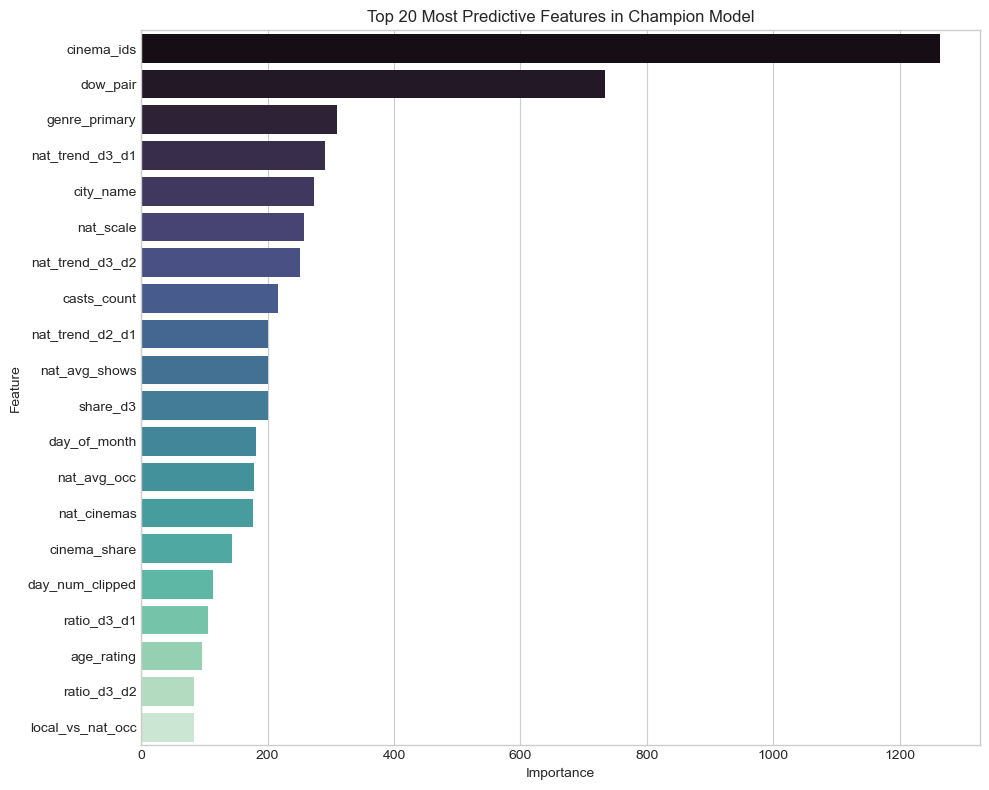

In [9]:
imp_df = pd.DataFrame({
    'feature': features,
    'importance': models_saved['lgb'][0].feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=imp_df.head(20), x='importance', y='feature', palette='mako')
plt.title('Top 20 Most Predictive Features in Champion Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## 10. Model Persistence & TM Verification
Saving model weights into `weights/champion_models.pkl` and verifying compliance with the $\le 200$ MB limit.


In [10]:
os.makedirs('weights', exist_ok=True)
weights_path = 'weights/champion_models.pkl'
with open(weights_path, 'wb') as f:
    pickle.dump({
        'weights': (w1, w2, w3),
        'opt_c': opt_c,
        'features': features,
        'models': models_saved
    }, f)

file_size_mb = os.path.getsize(weights_path) / (1024 * 1024)
print(f"Model Weights File Size: {file_size_mb:.2f} MB (Limit: 200 MB)")
assert file_size_mb <= 200.0, "Model weights exceed 200 MB limit!"
print("Model weight verification passed!")


Model Weights File Size: 45.02 MB (Limit: 200 MB)
Model weight verification passed!


## 11. Final Inference & Submission Export


In [11]:
test_final_blend = (w1 * test_lgb + w2 * test_cat + w3 * test_xgb) * opt_c
final_test_tickets = np.clip(test_final_blend * scale_test, 0, None)

df_test['pred_total_ticket'] = final_test_tickets
sub = df_test[['id', 'pred_total_ticket']].copy()
sub.columns = ['id', 'total_ticket']
sub = sub.sort_values('id')

os.makedirs('submissions', exist_ok=True)
sub_path = 'submissions/submission_champion_top1.csv'
sub.to_csv(sub_path, index=False)
print(f"Successfully generated {sub_path} with {len(sub):,} rows!")
display(sub.head(10))


Successfully generated submissions/submission_champion_top1.csv with 72,611 rows!


,id,total_ticket
0,1,38.380184
1,2,37.417990
2,3,33.997277
3,4,29.710082
4,5,31.947673
5,6,62.628453
6,7,56.777326
7,8,94.959598
8,9,88.669338
9,10,79.953598
